Explanatory data analysis

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('tracks2026.csv')
df

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4pcpqfSn8tfm6vQMMZPjpM,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,1WM80A5a4xDtlndjqjZQIv,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,4drUfuJw6c9M5cXA8p7upO,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,6ULjJomtdRstnT9BPMAf9d,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


Each row is a track. There are 17 different columns. Three columns (track_id, explicit and track_genre) contain something else than numbers, rest contain numbers.

In [3]:
df['mode'].value_counts(dropna=False)

mode
1    1275
0     725
Name: count, dtype: int64

In [4]:
df['key'].value_counts(dropna=False)

key
0     243
1     193
7     192
9     187
5     184
2     173
8     157
11    154
6     152
4     147
10    143
3      75
Name: count, dtype: int64

In [5]:
df['time_signature'].value_counts(dropna=False)

time_signature
4    1838
3     115
1      27
5      20
Name: count, dtype: int64

Column 'mode' seems to be categorical, containing only values 0 or 1. Column 'key' is Pitch class map of integers 0-11 and also categorical. Column 'time_signature' is also categorical.

In [6]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,1960.000000,2000.000000,1960.000000,1960.000000,2000.000000,1961.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1960.000000,2000.000000
mean,39.805102,217806.433000,0.635897,0.632489,5.295500,400.575884,0.637500,0.078466,0.297378,0.030269,0.180715,0.539963,120.040092,3.912000
std,29.245904,56804.759189,0.138298,0.189087,3.567148,18065.717039,0.480842,0.076223,0.279793,0.119946,0.149938,0.236062,28.520528,0.425848
min,0.000000,60000.000000,0.185000,0.090900,0.000000,-21.089000,0.000000,0.022100,0.000007,0.000000,0.009860,0.035900,51.037000,1.000000
25%,1.750000,181210.000000,0.548000,0.507750,2.000000,-8.988000,0.000000,0.034475,0.052475,0.000000,0.093775,0.353000,96.956000,4.000000
50%,45.000000,211346.000000,0.646000,0.644000,5.000000,-6.924000,1.000000,0.047500,0.195500,0.000007,0.121000,0.536000,118.711500,4.000000
75%,65.000000,246069.750000,0.738000,0.780000,8.000000,-5.390000,1.000000,0.084950,0.490250,0.000638,0.221250,0.730000,139.746250,4.000000
max,100.000000,561133.000000,0.953000,0.996000,11.000000,800000.000000,1.000000,0.515000,0.990000,0.962000,0.986000,0.990000,205.895000,5.000000


Columns 'popularity', 'danceability', 'energy', 'loudness' and 'tempo' have missing values.

Let us look the numerical values in two parts, first columns 'popularity','duration_ms', 'danceability', 'energy', 'loudness', 'speechiness'.

<Axes: >

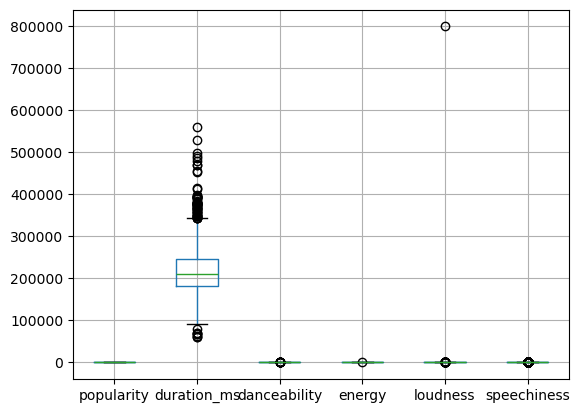

In [7]:
df[['popularity','duration_ms', 'danceability', 'energy', 'loudness', 'speechiness']].boxplot()

In [14]:
df[['popularity','duration_ms']].hist()
df[['danceability', 'energy']].hist()
df[['loudness', 'speechiness']].hist()

array([[<Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'speechiness'}>]], dtype=object)

As can be seen, duration, danceability, energy, loudness and speechines all have outliers. Also the scale of duration is far more dominant than other features. All of these columns are at least a bit skewed.

In [9]:
df[df['loudness']> 0]

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1289,39ujbBjTwwqUFySaCYDMMT,NaN,178604,False,NaN,NaN,1,800000.0,0,0.0851,0.485,0.0,0.318,0.49,NaN,4,pop


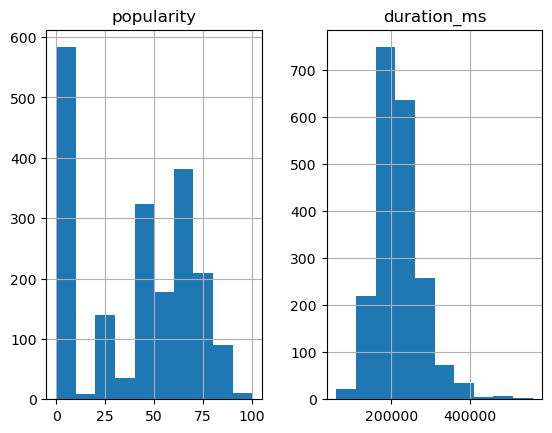

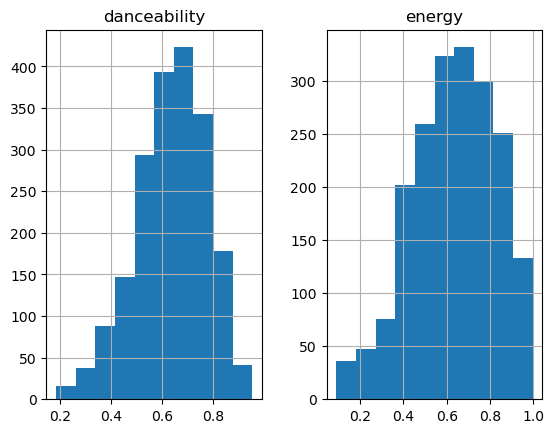

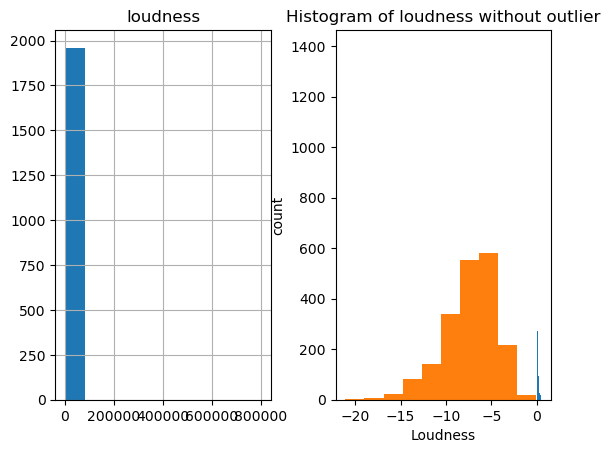

In [10]:
import matplotlib.pyplot as plt
loudness = df[df['loudness']<=0]['loudness'].to_numpy()
plt.hist(loudness)
plt.title('Histogram of loudness without outlier')
plt.xlabel('Loudness')
plt.ylabel('count')
plt.grid()
plt.show()

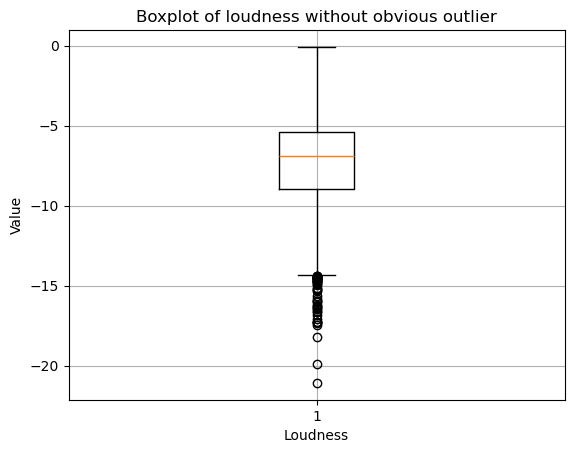

In [11]:
plt.boxplot(loudness)
plt.title('Boxplot of loudness without obvious outlier')
plt.xlabel('Loudness')
plt.ylabel('Value')
plt.grid()
plt.show()

There seems to be one incorrect datapoint in the loudness column (1289), as other values are negative and that is 800000.

Suggestion for data preparation of the columns 'popularity','duration_ms', 'danceability', 'energy', 'loudness', 'speechiness':
Drop the record of 1289.
For column popularity, use standard scaler and log transformation.
For columns rest columns, use robust scaler and log transformation.

Let us next explore columns 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'.

In [15]:
df[['acousticness', 'instrumentalness']].hist()
df[['liveness', 'valence', 'tempo']].hist()

array([[<Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'valence'}>],
       [<Axes: title={'center': 'tempo'}>, <Axes: >]], dtype=object)

In [16]:
df[['acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']].boxplot()

<Axes: >